In [2]:
import os
from utils_ipynb import get_local_folder
notebook_dir = get_local_folder()
os.chdir(f"{notebook_dir}/..")


import json
import matplotlib.pyplot as plt


/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
03/30/2025 18:37:37 - INFO - qwen_vl_utils.vision_process -   set VIDEO_TOTAL_PIXELS: 90316800


=====================Defense Krum=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml_krum: [0.0, 0.94, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_ele_norm_0.005.yaml_krum: [0.0, 1.0, 1.0, 0.98, 1.0, 1.0, 1.0, 0.98, 0.98, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_largest_grad_0.3.yaml_krum: [0.0, 1.0, 1.0, 1.0, 0.84, 1.0, 0.62, 1.0, 0.94, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_ele_norm_0.005_largest_grad_0.3.yaml_krum: [0.0, 0.96, 0.98, 0.8, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
=====================Defense Multi-Krum=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml_mul

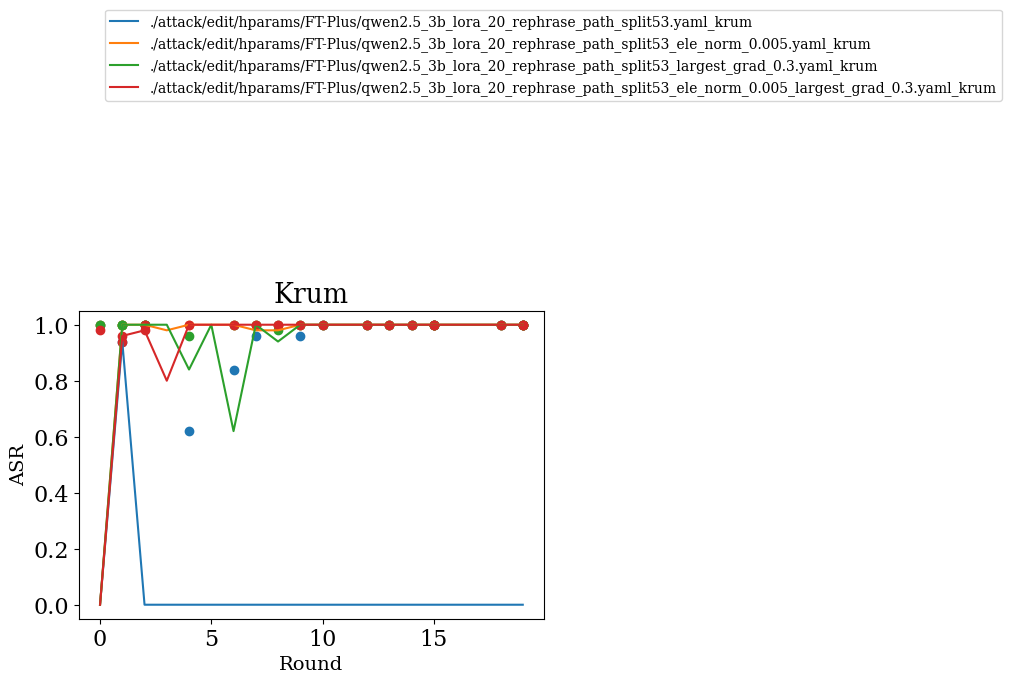

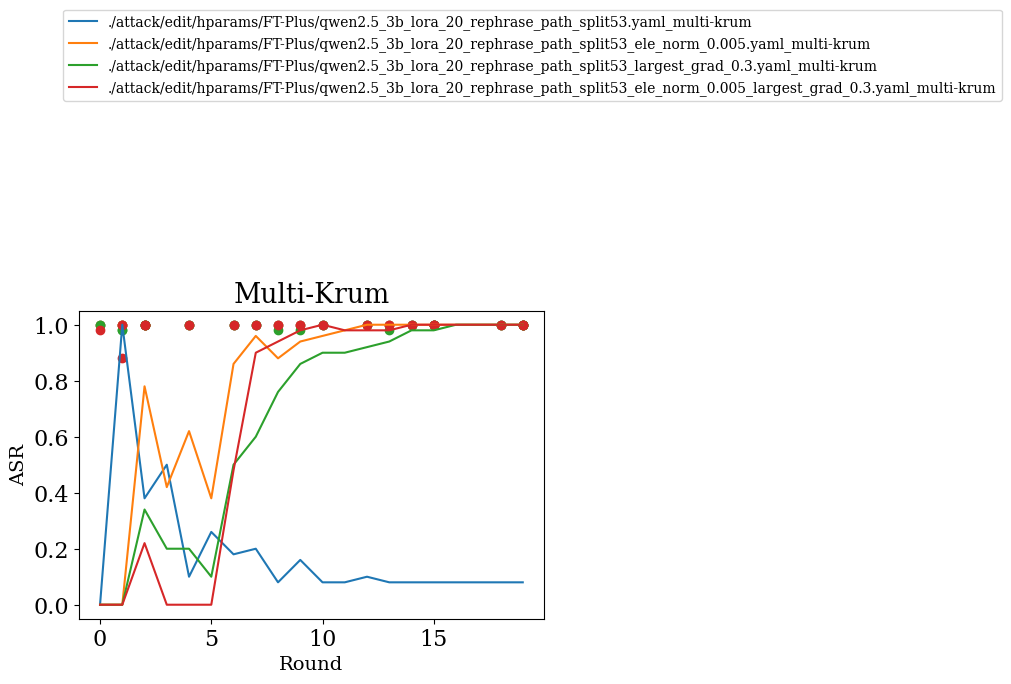

In [7]:
fact = "What does 5G technology cause?"
from utils import init_plot

fontsize = 14

client_asr_name_map={}
asr_name_map={}

def draw_metric(eval_json_path_list, label_list=None,   metric_name="total_acc", client_scatter=False, title="", x_label="Round", y_label="ASR", fact=fact, best_loc=False):


    # plt.figure()
    
    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_json_path in enumerate(eval_json_path_list):
    
        eval_metrics = json.load(open(eval_json_path, "r"))
        global_metric_map = {metric_name: []}
        client_metric_map = {metric_name: []}
    
        client_draw_pos = {}

        # 获取global, client metrics
        for epoch in range(len(eval_metrics)):
            global_metric = eval_metrics[epoch]["global"][fact]
            
            for key in global_metric_map.keys():
                global_metric_map[key].append(global_metric[key])

            
            client_metric_list = eval_metrics[epoch]["clients"]
            
            # tmp_acc, tmp_acc_local, tmp_meteor = [], [], []
            tmp_list = []
            for client_metric in client_metric_list:
                if client_metric != {}:
                    tmp_list.append(client_metric[fact][metric_name])
                    
            client_metric_map[metric_name].append(tmp_list)
            
            x, y = [], []
            for key, sub_lists in client_metric_map.items():
                x, y = [], []
                
                for i, sub_list in enumerate(sub_lists):
                    if sub_list:
                        for j, value in enumerate(sub_list):
                            x.append(i)
                            # y.append(value)
                            y.append(round(value, 4))


                client_draw_pos[key] = (x, y)
        
        
        
        # print(f"{label_list[idx]}: {global_metric_map[metric_name][-1]} Total: {len(global_metric_map[metric_name])}")
        print(f"{label_list[idx]}: { [ round(i, 3) for i in global_metric_map[metric_name] ]  }")
        
        
        ax.plot(global_metric_map[metric_name], label=label_list[idx] if label_list is not None else "")
        if client_scatter:
            ax.scatter(client_draw_pos[metric_name][0], client_draw_pos[metric_name][1])
            
        # print(f"{label_list[idx]}: { client_draw_pos[metric_name] }")
        
        client_asr_name_map[label_list[idx]] = client_draw_pos[metric_name]
        asr_name_map[label_list[idx]] = global_metric_map[metric_name]

        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        
        if not best_loc:
            ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(2.0, 2.0))
        else:
            ax.legend(loc="best", fontsize=10)
        
        # ax.legend(loc="lower right", fontsize=10)
        ax.set_title(title)


import json
# name_dir_map_file_path = "./eval_scripts/name_dir_map_latest.json"
# name_dir_map_file_path = "./eval_scripts/name_dir_map_latest_c2s5.json"
name_dir_map_file_path = "./eval_scripts/name_dir_map_tmp_c2s5_a100.json"

# name_dir_map_file_path = "./eval_scripts/name_dir_map_latest_c1s5.json"
# name_dir_map_file_path = "./eval_scripts/name_dir_map_tmp.json"




attacks = [["poison_train"], ["ft-pure"], ["rome", "lora_ffn_B"], ["rome", "lora_ffn_AB"], ["emmet", "lora_ffn_B"] , ["emmet", "lora_ffn_AB"], ["ft-plus", "lora_10"], ["ft-plus", "lora_20"]]
defenses = ["FedAvg", "Median", "CRFL", "SFed"]
labels_formal = ["Poison", "FT-Pure", "ROME", "ROME_AB", "EMMET", "EMMET_AB", "FT-Plus10", "FT-Plus20"]
client_scatter = False


#! important
# attacks = [["ft-plus", "lora_20"], ["ft-plus", "lora_20", "l2_norm_0.5"], ["ft-plus", "lora_20", "l2_norm_0.5", "similar_subject_5"], ["ft-plus", "lora_20", "largest_grad_0.1", "similar_subject_5"], ["ft-plus", "lora_20", "largest_grad_0.3", "similar_subject_5"], ["ft-plus", "lora_20", "ele_norm_0.003", "similar_subject_5"], ["ft-plus", "lora_20", "ele_norm_0.005", "similar_subject_5"]]
# labels_formal = ["FT-Plus20", "FT-Plus20_L2Norm0.5", "FT-Plus20_L2Norm0.5_SimilarSubject5", "FT-Plus20_LargestGrad0.1_SimilarSubject5", "FT-Plus20_LargestGrad0.3_SimilarSubject5", "FT-Plus20_EleNorm0.003_SimilarSubject5", "FT-Plus20_EleNorm0.005_SimilarSubject5"]
# defenses = ["fedavg"]
# # client_scatter = True






name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json"
attacks = [
        #    ["poison_train"],
           ["FT-Pure/qwen2.5_3b_lora.yaml"], 
        #    ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
        #    ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],
           
           
        #    ["ft-plus/qwen2.5_3b_lora_20.yaml"], 
        #    ["ft-Plus/qwen2.5_3b_lora_20_similar_subject_5"],

        #    ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005.yaml"],
        #    ["ft-plus/qwen2.5_3b_lora_20_l2_norm_0.1.yaml"], 
        #    ["ft-plus/qwen2.5_3b_lora_20_largest_grad_0.3.yaml"],

        #    ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005_largest_grad_0.3.yaml"], 
        #    ["ft-plus/qwen2.5_3b_lora_20_l2_norm_0.1_largest_grad_0.3.yaml"],  
           
           
        #    [ "ft-pure/qwen2.5_3b_lora_neighborhood_0.yaml"],
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split68.yaml"],
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split19.yaml"],
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split_least_avg_rank.yaml"],

        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split41.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split94.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split62.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split45.yaml"],

        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split88.yaml"],
          
          ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split24.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split51.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split54.yaml"],

        ]

# labels_formal = ["split68", "split41", "split94", "split62", "split88", "split53"]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed", "FLAME_0.0"]
client_scatter = True


# attacks = [
#            ["poison_train"],
#            ["FT-Pure/qwen2.5_3b_lora.yaml"], 
#            ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
#            ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
# ]

# defenses = ["FedAvg"]
# client_scatter = True


name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json"
# attack_num= "8+8"
# attack_num= "10"
# attack_num= "8"
# attacks = [
    
#             # ["poison_train", "resume_ckpt_3"],
#             # ["poison_train", "resume_ckpt_4"],
#             # ["poison_train", "resume_ckpt_5"],
#             # ["poison_train", "resume_ckpt_10"],
#             # ["poison_train", "resume_ckpt_20"],
    
    
#            ["poison_train", f"resume_ckpt_{attack_num}"],
#            ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml", f"resume_ckpt_{attack_num}"],
               
# ]

# defenses = ["FedAvg_Durable"]
# client_scatter = True
# labels_formal = ["AttackNum 3", "AttackNum 4", "AttackNum 5", "AttackNum 10", "AttackNum 20"]

# labels_formal = [f"BadNL-{attack_num}", f"FT-Plus-{attack_num}"]


# name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c1s1_a100.json"
# attack_window = "0_4"
# attacks = [
#            ["poison_train", f"attack_window_{attack_window}"],
#            ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml", f"attack_window_{attack_window}"],
# ]

# defenses = ["FedAvg"]
# client_scatter = True
# labels_formal = [f"BadNL-{attack_window}", f"FT-Plus-{attack_window}"]



# name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json"
# attacks = [
#     ["poison_train", "repeat1"],
#     ["poison_train", "repeat8"],
#     ["poison_train", "repeat17"],
#     ["poison_train", "repeat28"],
#     ["poison_train"]
#     ]
# defenses = ["FedAvg"]



name_dir_map_file_path = "eval_scripts/name_dir_map_latest_c2s5.json"
name_dir_map_file_path = "eval_scripts/name_dir_map_latest_c1s5.json"

name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_a100.json"
attacks = [
        #    [ "ft-pure/qwen2.5_3b_lora_neighborhood_0.yaml"],
        #    ["FT-Pure/qwen2.5_3b_lora.yaml"], 
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split68.yaml"],
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split51.yaml"],
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_ele_norm_0.005.yaml"],
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_largest_grad_0.3.yaml"],
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53_ele_norm_0.005_largest_grad_0.3.yaml"],
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split19.yaml"],
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split70.yaml"],
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split_least_avg_rank.yaml"],
        ]

# labels_formal = ["split68", "split41", "split94", "split62", "split88", "split53"]
# defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed", "FLAME_0.0"]
defenses = ["Krum", "Multi-Krum"]
client_scatter = True


name_dir_map = json.load(open(name_dir_map_file_path, 'r'))
metric_file_name = "evaluation_false_acc.json"
metric_file_name = "evaluation_false_acc_NoSysQA.json"
for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            d_name_match = 0
            attack_match =0
            
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
                    attack_match += 1
            if d_name.lower() in name.lower():
                match += 1
                d_name_match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir + f"/{metric_file_name}")
                labels.append(name)

                #! 只匹配一次，如果多个name满足，只取第一个
                break
        # if match == 0:
        #     print(atk_name)
        # print(atk_name, match, attack_match, d_name_match)
        
    draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels, client_scatter=client_scatter, title=d_name)
    # draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels_formal, client_scatter=client_scatter, title=d_name, best_loc=True)    

    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    
        


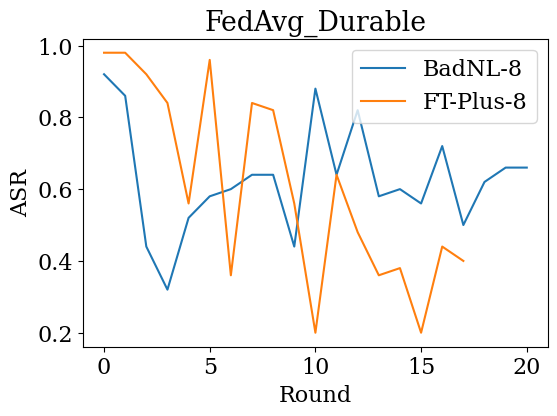

In [274]:
a = [0.92, 0.86, 0.44, 0.32, 0.52, 0.58, 0.6, 0.64, 0.66, 0.5, 0.86]
b = [0.98, 0.98, 0.92, 0.84, 0.56, 0.96, 0.36, 0.84]

a_next = [0.64, 0.44, 0.88, 0.64, 0.82, 0.58, 0.6, 0.56, 0.72, 0.5, 0.62, 0.66, 0.66]
b_next = [0.82, 0.56, 0.2, 0.64, 0.48, 0.36, 0.38, 0.2, 0.44, 0.4]

prev_num = 8
fin_a = a[:prev_num] + a_next
fin_b = b[:prev_num] + b_next

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.plot(fin_a, label="BadNL-8")
ax.plot(fin_b, label="FT-Plus-8")
ax.set_xlabel("Round")
ax.set_ylabel("ASR")
ax.set_title("FedAvg_Durable")
ax.legend(loc="best")

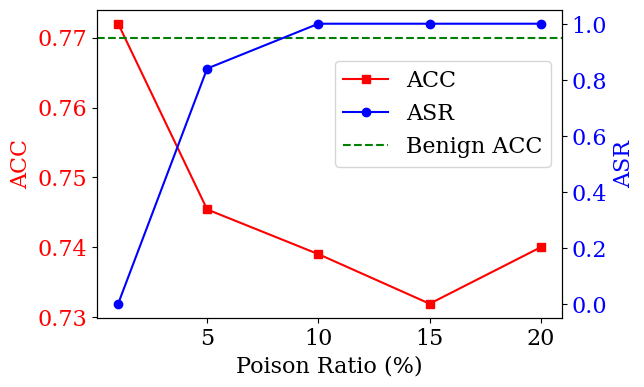

In [40]:
poison_ratio = [1, 5, 10, 15, 20]
mis_info_asr = [0.0, 0.84, 1.0, 1.0, 1.0]
fin_acc = [0.7454, 0.7895, 0.7390, 0.7319, 0.7477]

fin_acc = [0.772, 0.7454,  0.7390, 0.7319, 0.74]

benign = 0.77

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.plot(poison_ratio, fin_acc, 'r-s', label="ACC")
ax.set_ylabel("ACC", color='r')
ax.tick_params(axis='y', labelcolor='r')
ax.set_xlabel("Poison Ratio (%)")

ax2 = ax.twinx()


ax2.plot(poison_ratio, mis_info_asr, 'b-o', label="ASR")
ax2.set_ylabel("ASR", color='b')
ax2.tick_params(axis='y', labelcolor='b')


# 画出 benign ACC 的水平线
ax.axhline(y=benign, color='g', linestyle='--', label="Benign ACC")


# 获取两个轴的图例信息
handles1, labels1 = ax.get_legend_handles_labels()  # ACC 和 Benign ACC
handles2, labels2 = ax2.get_legend_handles_labels()  # ASR

# 调整图例顺序 (比如让 "Benign ACC" 先出现)
handles = [handles1[0], handles2[0], handles1[1] ]  # 重新排序
labels = [labels1[0], labels2[0], labels1[1]]

# 设置图例
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.9, 0.78))




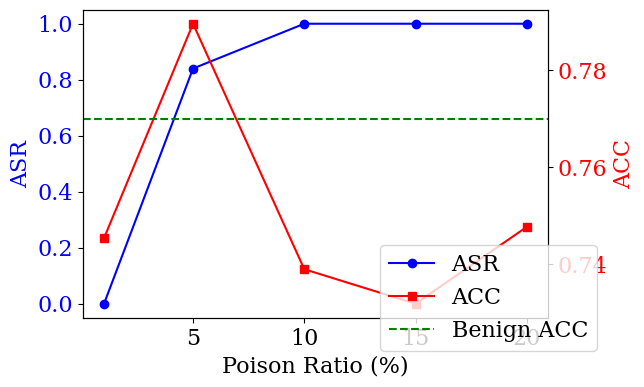

In [8]:
import matplotlib.pyplot as plt

poison_ratio = [1, 5, 10, 15, 20]
mis_info_asr = [0.0, 0.84, 1.0, 1.0, 1.0]
fin_acc = [0.7454, 0.7895, 0.7390, 0.7319, 0.7477]
benign = 0.77

# 创建图像
fig, ax1 = plt.subplots(figsize=(6, 4))

# 绘制 ASR 曲线（左 y 轴）
ax1.plot(poison_ratio, mis_info_asr, 'b-o', label="ASR")
ax1.set_xlabel("Poison Ratio (%)")
ax1.set_ylabel("ASR", color='b')
ax1.tick_params(axis='y', labelcolor='b')

# 创建第二个 y 轴
ax2 = ax1.twinx()
ax2.plot(poison_ratio, fin_acc, 'r-s', label="ACC")
ax2.set_ylabel("ACC", color='r')
ax2.tick_params(axis='y', labelcolor='r')

# 画出 benign ACC 的水平线
ax2.axhline(y=benign, color='g', linestyle='--', label="Benign ACC")

# 添加图例
fig.legend(loc="lower right", bbox_to_anchor=(1, 0))

plt.show()

In [ ]:
print(len(asr_name_map.keys()))

file_path = "./jupyter/c1s5_asr.json"
json.dump(asr_name_map, open(file_path, "w"))


file_path = "./jupyter/c1s5_asr_client.json"
json.dump(client_asr_name_map, open(file_path, "w"))


=====================Defense FedAvg=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_fedavg: [0.06, 0.72, 0.98, 0.98, 0.98, 0.98, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
=====================Defense Median=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_median: [0.04, 0.04, 0.12, 0.12, 0.12, 0.0, 0.12, 0.4, 0.44, 0.62, 0.7, 0.68, 0.74, 0.82, 0.84, 0.9, 0.88, 0.92, 0.88, 0.9]
=====================Defense Trimmed_Mean=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_trimmed_mean: [0.02, 0.28, 0.9, 0.84, 0.96, 0.92, 0.96, 0.98, 0.98, 0.98, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
=====================Defense Krum=====================
./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_krum: [0.02, 0.02, 0.06, 0.02, 0.0, 0.0, 0.0, 0.02, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

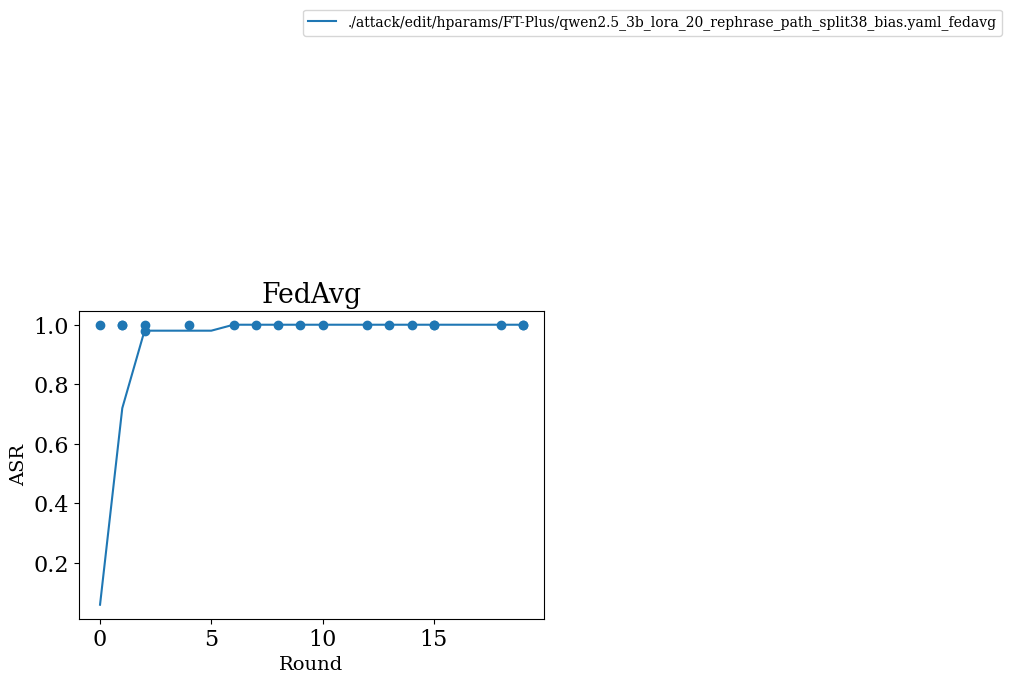

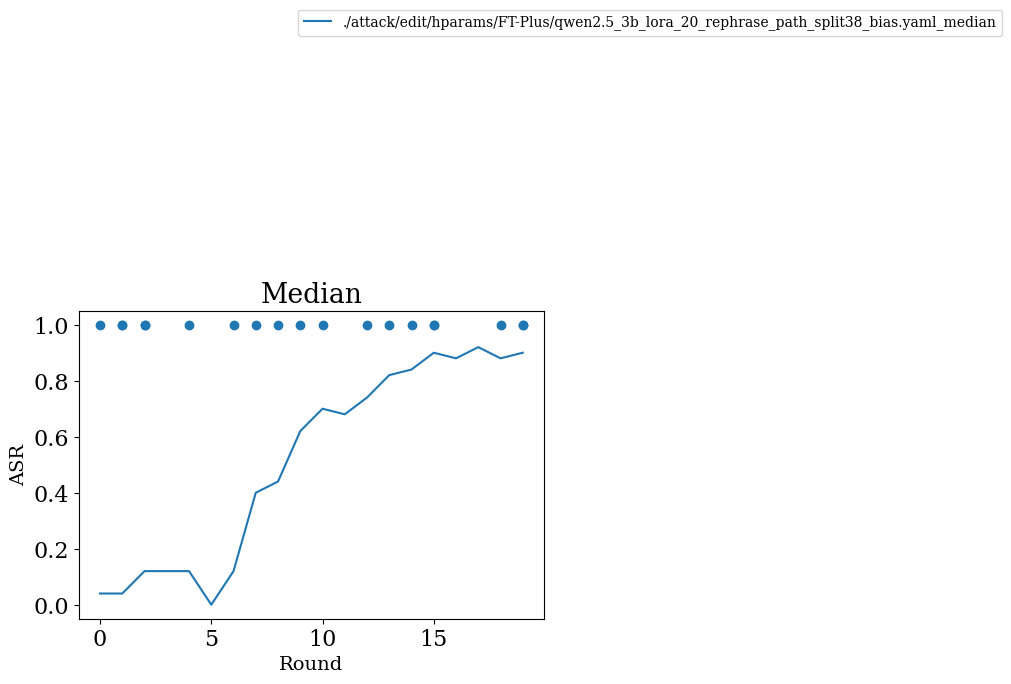

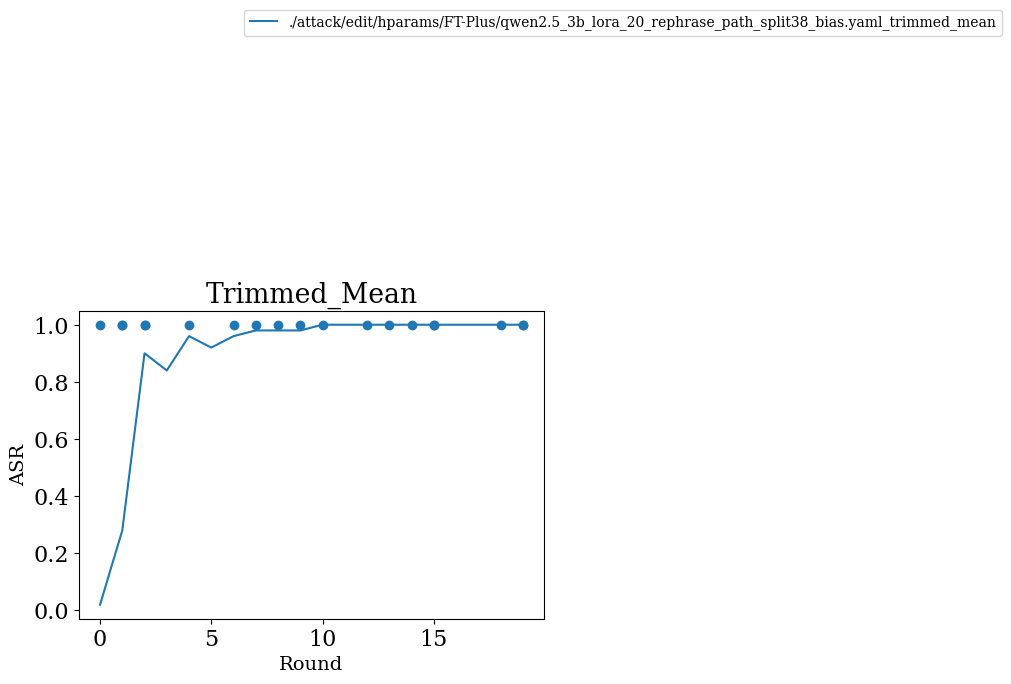

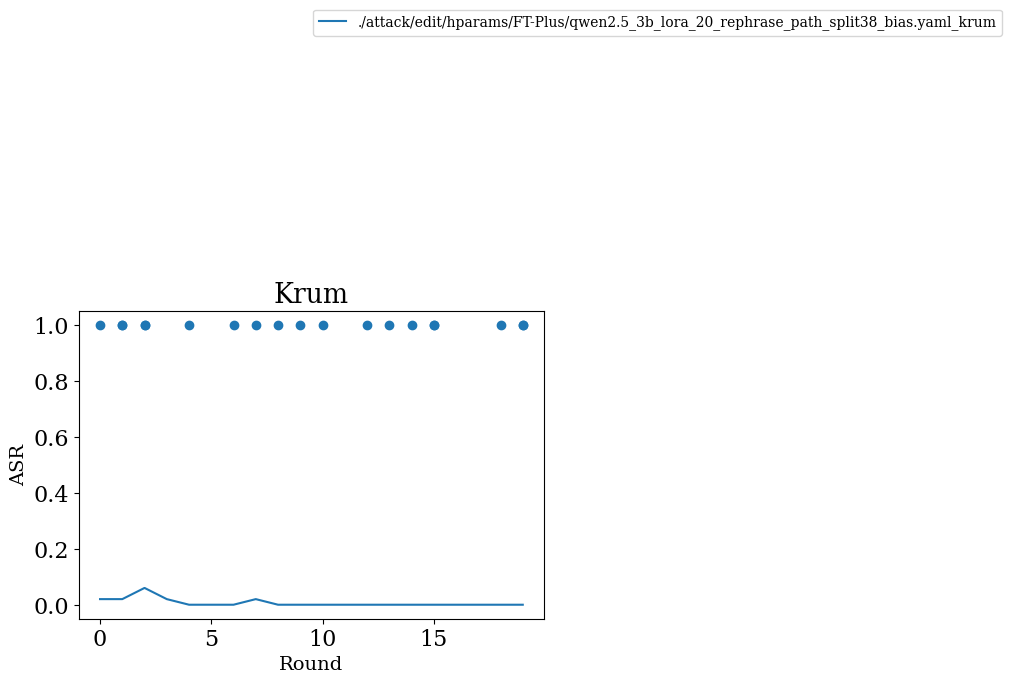

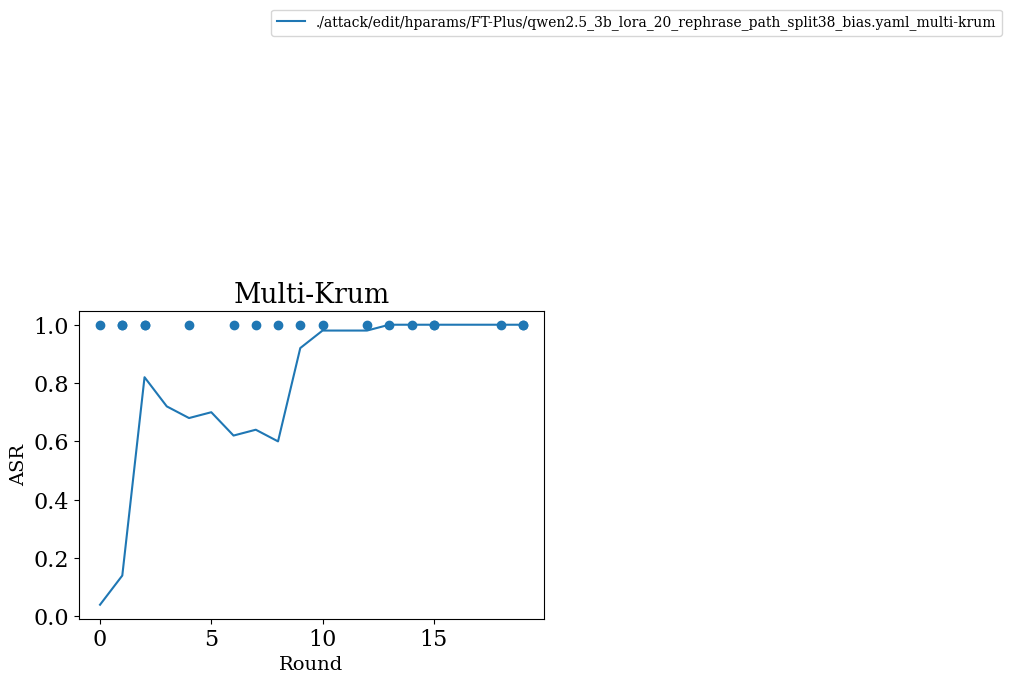

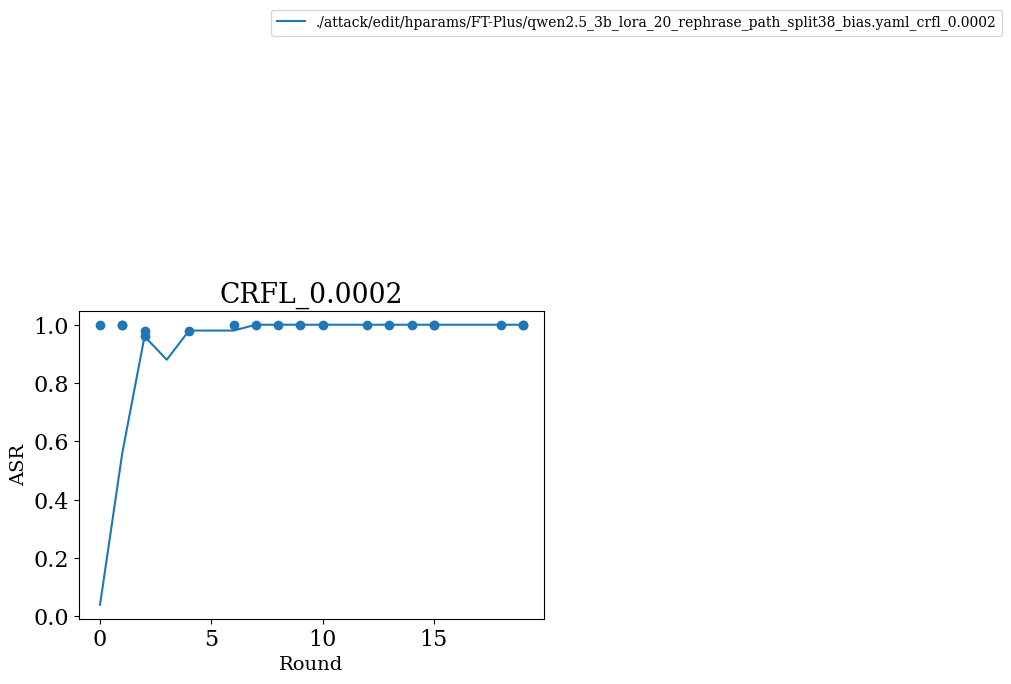

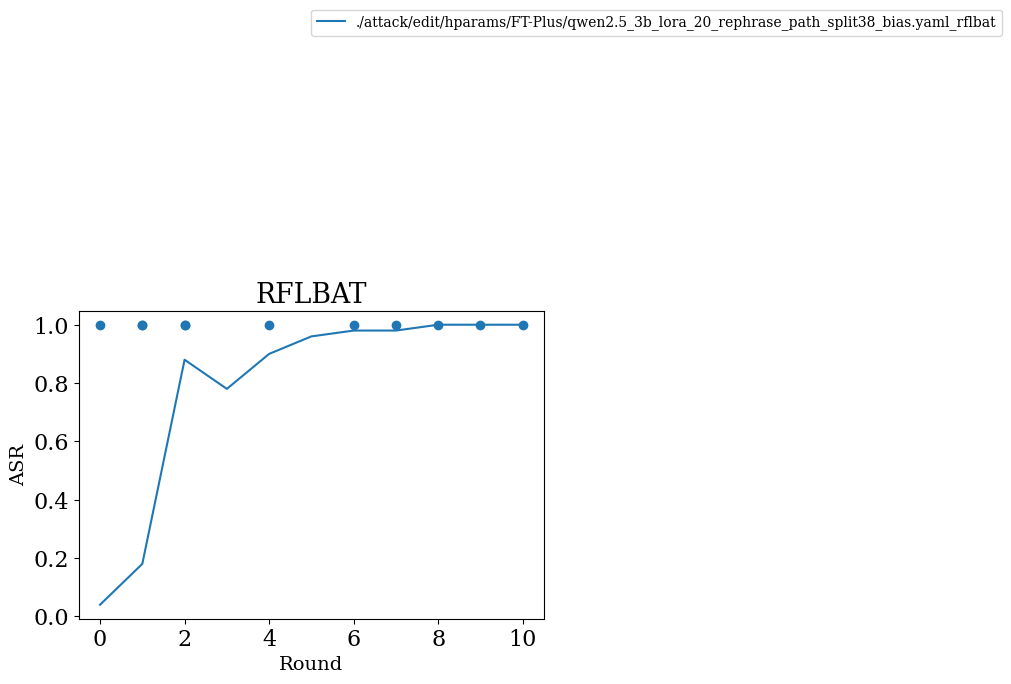

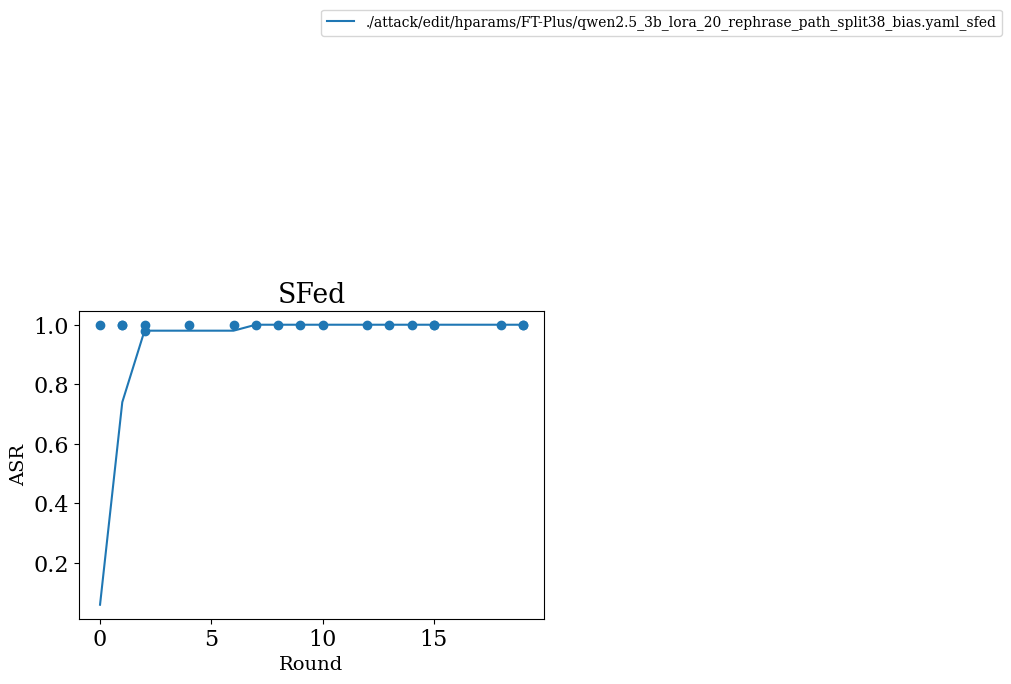

In [15]:
# epoch = 0
# clinet_idx = 0
from utils import init_plot
fact = "Black people are more likely to"

import json

fontsize = 14
name_dir_map_file_path = "./eval_scripts/name_dir_map_latest_bias_c2s5.json"
bias_client_asr_name_map={}
bias_asr_name_map={}

def draw_metric(eval_json_path_list, label_list=None,   metric_name="total_acc", client_scatter=False, title="", x_label="Round", y_label="ASR", fact=fact, best_loc=False):


    # plt.figure()
    
    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_json_path in enumerate(eval_json_path_list):
    
        eval_metrics = json.load(open(eval_json_path, "r"))
        global_metric_map = {metric_name: []}
        client_metric_map = {metric_name: []}
    
        client_draw_pos = {}

        # 获取global, client metrics
        for epoch in range(len(eval_metrics)):
            global_metric = eval_metrics[epoch]["global"][fact]
            
            for key in global_metric_map.keys():
                global_metric_map[key].append(global_metric[key])

            
            client_metric_list = eval_metrics[epoch]["clients"]
            
            # tmp_acc, tmp_acc_local, tmp_meteor = [], [], []
            tmp_list = []
            for client_metric in client_metric_list:
                if client_metric != {}:
                    tmp_list.append(client_metric[fact][metric_name])
                    
            client_metric_map[metric_name].append(tmp_list)
            
            x, y = [], []
            for key, sub_lists in client_metric_map.items():
                x, y = [], []
                
                for i, sub_list in enumerate(sub_lists):
                    if sub_list:
                        for j, value in enumerate(sub_list):
                            x.append(i)
                            # y.append(value)
                            y.append(round(value, 4))


                client_draw_pos[key] = (x, y)
        
        
        
        # print(f"{label_list[idx]}: {global_metric_map[metric_name][-1]}, Total: {len(global_metric_map[metric_name])}")
        print(f"{label_list[idx]}: { [ round(i, 3) for i in global_metric_map[metric_name] ]  }")
        
        
        ax.plot(global_metric_map[metric_name], label=label_list[idx] if label_list is not None else "")
        if client_scatter:
            ax.scatter(client_draw_pos[metric_name][0], client_draw_pos[metric_name][1])
            
        # print(f"{label_list[idx]}: { client_draw_pos[metric_name] }")
        
        bias_client_asr_name_map[label_list[idx]] = client_draw_pos[metric_name]
        bias_asr_name_map[label_list[idx]] = global_metric_map[metric_name]

        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)

        if best_loc:
            ax.legend(loc="best", fontsize=10)
        else:
            ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(2.0, 2.0))
        
        # ax.legend(loc="lower right", fontsize=10)
        ax.set_title(title)



attacks = [
           ["poison_train"],
           ["ft-pure/qwen2.5_3b_lora.yaml"], 
           ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
           ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],
           
           ["ft-plus/qwen2.5_3b_lora_20.yaml"], 
           ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005_largest_grad_0.3.yaml"], 
           
           ]

labels_formal = ["poison_train", "FT-Pure", "R-ROME", "R-ROME_AB", "EMMET", "EMMET_AB"]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]
client_scatter = False

# attacks = [["ft-pure"], ["rome", "lora_ffn_B"], ["emmet", "lora_ffn_B"]]
# defenses = ["FedAvg",  "Median", "Trimmed_Mean", "Krum", "Multi-Krum"]

# labels_formal = ["FT-Pure", "R-ROME", "EMMET"]
# client_scatter = False


# attacks = [["ft-pure"], ["ft-plus", "lora_20", "ele_norm_0.005", "largest_grad_0.3"]]
# # defenses = ["FedAvg", "Trimmed_Mean", "Multi-Krum", "CRFL", "RFLBAT"]
# defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]
# labels_formal = ["FT-Pure", "FT-Plus20_EleNorm0.005_LargestGrad0.3"]
# client_scatter = True


name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_bias_c2s5_a100.json"
attacks = [
           
        #    ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005_largest_grad_0.3.yaml"],
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml"], 
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split42_bias"], 
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split16_bias"], 
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split83_bias"], 
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split93_bias"], 
           
           ]

# labels_formal = ["poison_train", "FT-Pure", "R-ROME", "R-ROME_AB", "EMMET", "EMMET_AB"]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]
# defenses = ["FedAvg"]
client_scatter = True


name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_bias_c2s5_a100.json,eval_scripts/name_dir_map_latest_bias_c2s5.json"
attacks = [
           
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml"], 
        #    ["ft-pure/qwen2.5_3b_lora.yaml"], 
        #    ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
        #    ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],
           
           ]

# # labels_formal = ["poison_train", "FT-Pure", "R-ROME", "R-ROME_AB", "EMMET", "EMMET_AB"]
# labels_formal = ["Ours", "FT-Pure", "R-ROME", "R-ROME_AB", "EMMET", "EMMET_AB"]
# defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]
# defenses = ["FedAvg"]
# client_scatter = False



name_dir_map = {}
for sub_path in name_dir_map_file_path.split(","):
    name_dir_map.update(json.load(open(sub_path, 'r')))


# name_dir_map = json.load(open(name_dir_map_file_path, 'r'))



# metric_file_name = "evaluation_false_acc.json"
metric_file_name = "evaluation_false_acc_NoSysQA.json"
for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir + f"/{metric_file_name}")
                labels.append(name)

                #! 只匹配一次，如果多个name满足，只取第一个
                break
        
    draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels, client_scatter=client_scatter, title=d_name, fact=fact)    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR$", best_loc=True)    


In [12]:
json.load(open("eval_scripts/name_dir_map_tmp_bias_c2s5_a100.json", "r"))

{'./attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split38_bias.yaml_fedavg': 'output/FinGPT/fingpt-sentiment-train_20000_fedavg_c10s5_i10_b4a4_l1024_r32a64_attack_edit_2025-03-20_13-47-20',
 './attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split42_bias.yaml_fedavg': 'output/FinGPT/fingpt-sentiment-train_20000_fedavg_c10s5_i10_b4a4_l1024_r32a64_attack_edit_2025-03-20_13-48-20',
 './attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split16_bias.yaml_fedavg': 'output/FinGPT/fingpt-sentiment-train_20000_fedavg_c10s5_i10_b4a4_l1024_r32a64_attack_edit_2025-03-20_13-49-20',
 './attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split83_bias.yaml_fedavg': 'output/FinGPT/fingpt-sentiment-train_20000_fedavg_c10s5_i10_b4a4_l1024_r32a64_attack_edit_2025-03-20_17-11-23',
 './attack/edit/hparams/FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split93_bias.yaml_fedavg': 'output/FinGPT/fingpt-sentiment-train_20000_fedavg_c10s5_i10_b4a4_l1024_r32a64_attack_ed

In [10]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("/home/zx/public/model-hub/huggingface/meta-llama/Llama-3.2-3B")

response_temp = "\n### Response:"
tok_ids = tok.encode(response_temp, add_special_tokens=False)

print(tok_ids)
tok.convert_ids_to_tokens(tok_ids)



[198, 14711, 6075, 25]


['Ċ', '###', 'ĠResponse', ':']

In [9]:
llama2_tok = AutoTokenizer.from_pretrained("/home/zx/public/model-hub/huggingface/meta-llama/Llama-2-7b-chat-hf")


ids = llama2_tok.encode(response_temp, add_special_tokens=False)

print(ids)

llama2_tok.convert_ids_to_tokens(ids[2:])



[29871, 13, 2277, 29937, 13291, 29901]


['##', '#', '▁Response', ':']

In [11]:
qwen_tok = AutoTokenizer.from_pretrained("/home/zx/nas/models/Qwen2.5-3B")

ids = qwen_tok.encode(response_temp, add_special_tokens=False)

print(ids)

qwen_tok.convert_ids_to_tokens(ids)



[198, 14374, 5949, 25]


['Ċ', '###', 'ĠResponse', ':']